# **Machine Learning**

Now that we have our baseline RMSE, we want to create machine learning models which improve that score, so that we have an even more powerful tool to use in predicting volatility.

This notebook will focus on running different models, selecting the promising ones and fine tuning to make sure we get the best possible model.

### **Training and Validation data**

We will use the same split as we did for our baselines.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, cross_val_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.impute import KNNImputer
from sklearn.metrics import root_mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import seaborn as sns

In [2]:
train = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/train.csv")
val = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/validation.csv")

In [3]:
train = train.drop(["future_vol_5", "future_vol_20"], axis = 1)
val = val.drop(["future_vol_5", "future_vol_20"], axis = 1)

Models to try  out:
- Linear Regression
- Decision Trees
- Random Forests
- Lasso Regression
- Ridge Regression
- Elastic Net
- K-Nearest Neighours
- Gradient Boosting Regressor
- AdaBoost Regressor
- XGBoost
- LightGBM
- CatBoost
- LSTM


In [4]:
X_train = train.drop(["future_vol_10"], axis = 1)
y_train = train["future_vol_10"]


X_val = val.drop(["future_vol_10"], axis = 1)
y_val = val["future_vol_10"]

In [5]:
X_train.dtypes

Unnamed: 0      int64
Date           object
Open          float64
High          float64
Low           float64
Close         float64
Volume        float64
log_return    float64
return_5d     float64
return_10d    float64
return_20d    float64
vol_5         float64
vol_10        float64
vol_20        float64
hl_range      float64
oc_range      float64
vol_change    float64
vol_ratio     float64
dtype: object

In [6]:
X_train = X_train.drop("Date", axis=1)
X_val = X_val.drop("Date", axis=1)

In [7]:
X_train = X_train.drop(["Unnamed: 0"],axis = 1)
X_val = X_val.drop(["Unnamed: 0"], axis = 1)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#### Baseline Models 

This is to see which models are promising and worth tuning

In [9]:
models = {
    "LinearRegression":{"model": LinearRegression()},
    "Ridge":{"model": Ridge()},
    "ElasticNet": {"model": ElasticNet()},
    "DecisionTreeRegressor": {"model": DecisionTreeRegressor(random_state=1)},
    "RandomForestRegressor": {"model": RandomForestRegressor(random_state=1)},
    "GradientBoostingRegressor": {"model": GradientBoostingRegressor(random_state=1)},
    "KNeighborsRegressor": {"model": KNeighborsRegressor()},
    "XGB": {"model": XGBRegressor(random_state=17, objective="reg:squarederror")},
    "LightGBM": {"model": LGBMRegressor(random_state=17, verbose=-1)},
    "CatBoost": {"model": CatBoostRegressor(random_state=17, verbose=False)},
    "AdaBoostRegressor": {"model": AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=17)}
    }

In [10]:
scores = pd.DataFrame(columns=[
    "Model",
    "RMSE_Train",
    "RMSE_Val",
    "MSE_Train",
    "MSE_Val",
    "MAE_Train",
    "MAE_Val",
    "R2_Train",
    "R2_Val"
])

for name, regressor in models.items():
    print("Running: ", name)
    regressor["model"].fit(X_train, y_train)
    y_pred = regressor["model"].predict(X_val)
    y_train_pred = regressor["model"].predict(X_train)

    mae_val = metrics.mean_absolute_error(y_val, y_pred)
    mse_val = metrics.mean_squared_error(y_val, y_pred)
    rmse_val = np.sqrt(metrics.mean_squared_error(y_val, y_pred))
    r2_val = metrics.r2_score(y_val, y_pred)

    mae_train = metrics.mean_absolute_error(y_train, y_train_pred)
    mse_train = metrics.mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
    r2_train = metrics.r2_score(y_train, y_train_pred)

    print('\n'.join([f'MAE  val:   {mae_val}',
                     f'MSE  val:   {mse_val}',
                     f'RMSE val:   {rmse_val}',
                     f'R2   val:   {r2_val}\n']))
    
    print('\n'.join([f'MAE  TRAIN:  {mae_train}',
                     f'MSE  TRAIN:  {mse_train}',
                     f'RMSE TRAIN:  {rmse_train}',
                     f'R2   TRAIN:  {r2_train}\n']))
    
    print("*************************\n")

    scores = scores._append({
        "Model": name,
        "RMSE_Train": rmse_train,
        "RMSE_Val": rmse_val,
        "MSE_Train": mse_train,
        "MSE_Val": mse_val,
        "MAE_Train": mae_train,
        "MAE_Val": mae_val,
        "R2_Train": r2_train,
        "R2_Val": r2_val}, ignore_index=True)

Running:  LinearRegression
MAE  val:   0.003850037801550636
MSE  val:   3.415964438714786e-05
RMSE val:   0.005844625256348593
R2   val:   0.04008474451776778

MAE  TRAIN:  0.0029532245003835293
MSE  TRAIN:  2.1998011610315386e-05
RMSE TRAIN:  0.00469020379198126
R2   TRAIN:  0.5404785250534022

*************************

Running:  Ridge
MAE  val:   0.004162773739826093
MSE  val:   3.900192214658518e-05
RMSE val:   0.00624515189139425
R2   val:   -0.0959874065821138

MAE  TRAIN:  0.00316485929444382
MSE  TRAIN:  2.479857854958283e-05
RMSE TRAIN:  0.0049798171200941535
R2   TRAIN:  0.4819768443826189

*************************

Running:  ElasticNet
MAE  val:   0.003433637321240438
MSE  val:   3.5741108148360766e-05
RMSE val:   0.005978386751320189
R2   val:   -0.004355741254728596

MAE  TRAIN:  0.003964251605817699
MSE  TRAIN:  3.466289156905903e-05
RMSE TRAIN:  0.005887519984599546
R2   TRAIN:  0.27591896295486906

*************************

Running:  DecisionTreeRegressor
MAE  val:   

C:\Users\jungn\AppData\Local\Temp\ipykernel_8152\916529821.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scores = scores._append({
c:\Users\jungn\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.12427e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


MAE  val:   0.0034445650261011253
MSE  val:   4.577926748793426e-05
RMSE val:   0.006766037798293345
R2   val:   -0.28643661357913097

MAE  TRAIN:  0.0008162554114606891
MSE  TRAIN:  1.718236723671647e-06
RMSE TRAIN:  0.0013108152896848767
R2   TRAIN:  0.9641073617217859

*************************

Running:  GradientBoostingRegressor
MAE  val:   0.003280859724135201
MSE  val:   4.16469913526871e-05
RMSE val:   0.0064534480204528726
R2   val:   -0.17031611603726238

MAE  TRAIN:  0.0020627447914857754
MSE  TRAIN:  8.196004662702486e-06
RMSE TRAIN:  0.0028628665115059916
R2   TRAIN:  0.8287917918223044

*************************

Running:  KNeighborsRegressor
MAE  val:   0.0036651970660500173
MSE  val:   3.6591939431807243e-05
RMSE val:   0.006049127162806816
R2   val:   -0.02826482881914938

MAE  TRAIN:  0.003501880413411302
MSE  TRAIN:  2.7197853685183332e-05
RMSE TRAIN:  0.005215156151562802
R2   TRAIN:  0.4318578395996209

*************************

Running:  XGB
MAE  val:   0.0033084

In [11]:
# scores = scores.drop(["MAE","MSE","RMSE","R2"], axis = 1)

In [12]:
scores

,Model,RMSE_Train,RMSE_Val,MSE_Train,MSE_Val,MAE_Train,MAE_Val,R2_Train,R2_Val
0,LinearRegression,0.004690,0.005845,2.199801e-05,0.000034,0.002953,0.003850,0.540479,0.040085
1,Ridge,0.004980,0.006245,2.479858e-05,0.000039,0.003165,0.004163,0.481977,-0.095987
2,ElasticNet,0.005888,0.005978,3.466289e-05,0.000036,0.003964,0.003434,0.275919,-0.004356
3,DecisionTreeRegressor,0.000000,0.007876,0.000000e+00,0.000062,0.000000,0.004094,1.000000,-0.743052
4,RandomForestRegressor,0.001311,0.006766,1.718237e-06,0.000046,0.000816,0.003445,0.964107,-0.286437
5,GradientBoostingRegressor,0.002863,0.006453,8.196005e-06,0.000042,0.002063,0.003281,0.828792,-0.170316
6,KNeighborsRegressor,0.005215,0.006049,2.719785e-05,0.000037,0.003502,0.003665,0.431858,-0.028265
7,XGB,0.000972,0.005978,9.448790e-07,0.000036,0.000711,0.003308,0.980262,-0.004115
8,LightGBM,0.001685,0.005831,2.839973e-06,0.000034,0.001184,0.003314,0.940675,0.044534
9,CatBoost,0.001286,0.005497,1.653729e-06,0.000030,0.000979,0.003122,0.965455,0.150870


GARCH(1,1):
- MAE: 0.003600	
- RMSE: 0.005938

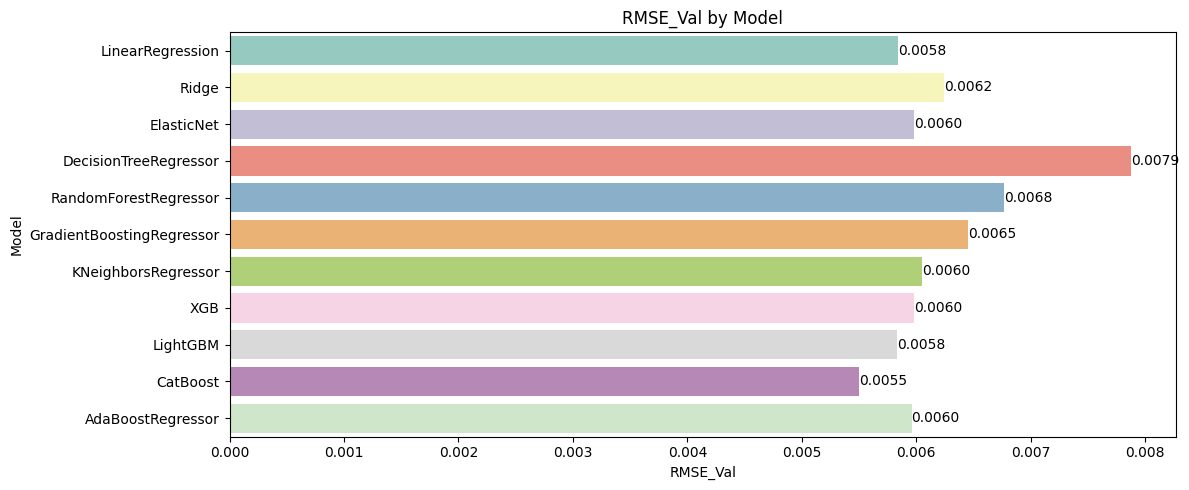

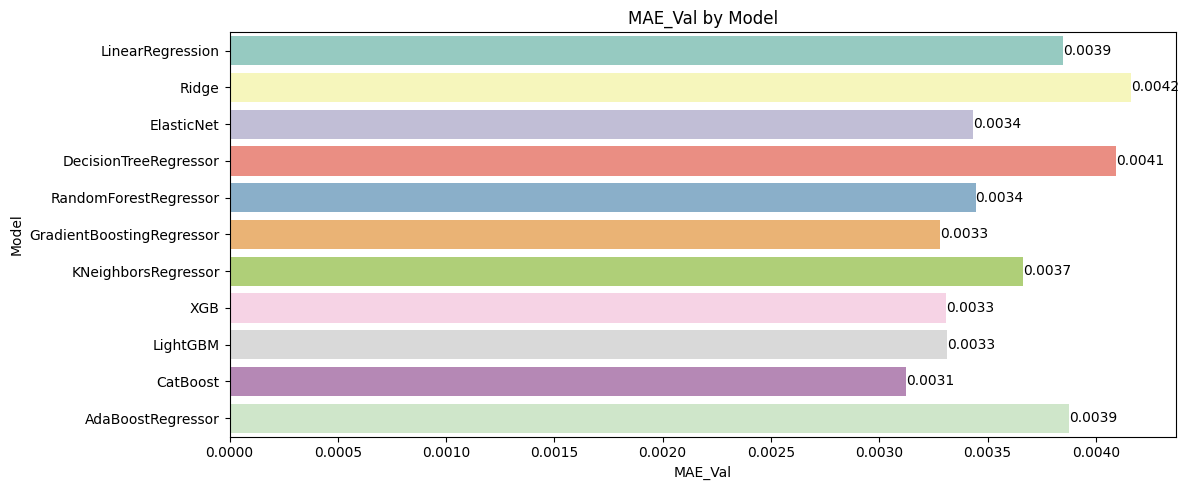

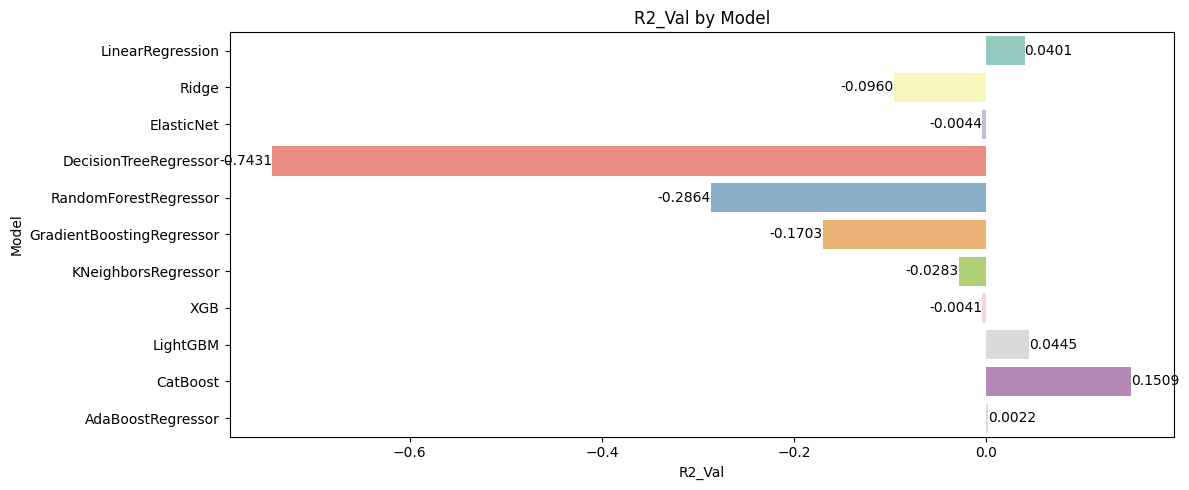

In [13]:
metrics_to_plot = [
    "RMSE_Val",
    "MAE_Val",
    "R2_Val"
]

for col in metrics_to_plot:

    plt.figure(figsize=(12,5))

    ax = sns.barplot(
        data=scores,
        x=col,
        y="Model",
        hue="Model",
        palette="Set3",
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="{:.4f}"
        )

    plt.title(f"{col} by Model")
    plt.tight_layout()
    plt.show()

We see that CatBoost and LightGBM are the highest performers

#### Overfitting/Underfitting 

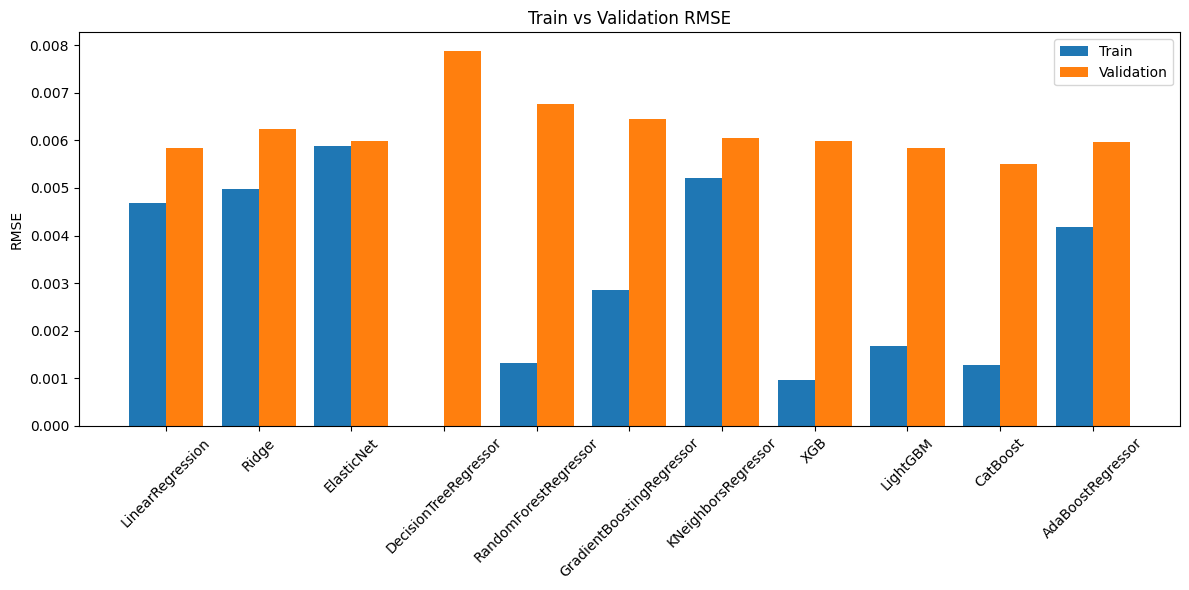

In [14]:
x = np.arange(len(scores))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    scores["RMSE_Train"],
    width,
    label="Train"
)

plt.bar(
    x + width/2,
    scores["RMSE_Val"],
    width,
    label="Validation"
)

plt.xticks(
    x,
    scores["Model"],
    rotation=45
)

plt.ylabel("RMSE")
plt.title("Train vs Validation RMSE")
plt.legend()

plt.tight_layout()
plt.show()

We see that LightGBM and CatBoost overfit somewhat, however they still do generalise better than the other models. This makes sense, since they are more flexible compared to models like ElasticNet which has low variance but higher bias. XGBoost performs well, but not well enough to justify the overfitting.

#### Feature importance

In [15]:
cat_model = models["CatBoost"]["model"]
lgbm_model = models["LightGBM"]["model"]

In [17]:
cat_model.predict(X_val[:5])

array([0.00781772, 0.008238  , 0.00869202, 0.0090557 , 0.00697008])

In [18]:
lgbm_model.predict(X_val[:5])

array([0.00753389, 0.0094446 , 0.0081515 , 0.00867697, 0.0068497 ])

In [19]:
cat_model.feature_importances_

array([ 6.6420863 ,  6.53307008,  5.51180705,  5.41148311,  3.23083131,
        1.9404427 ,  3.86115303, 10.88314731,  6.62109188, 18.21021416,
        8.41994627, 11.56968356,  4.07960765,  1.38835851,  1.95172652,
        3.74535056])

In [20]:
lgbm_model.feature_importances_

array([211, 130, 112,  97, 202, 168, 172, 288, 264, 240, 256, 277, 164,
       125, 123, 171], dtype=int32)

In [21]:
print(X_train.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'return_5d', 'return_10d', 'return_20d', 'vol_5', 'vol_10', 'vol_20', 'hl_range', 'oc_range', 'vol_change', 'vol_ratio']


In [22]:
cat_importance_df = pd.DataFrame({
    "feature": X_train.columns, 
    "importance": cat_model.feature_importances_
})

In [24]:
lgbm_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
})

In [29]:
cat_importance_df = cat_importance_df.sort_values(
    "importance",
    ascending=False
)

cat_importance_df

,feature,importance
9,vol_5,18.210214
11,vol_20,11.569684
7,return_10d,10.883147
10,vol_10,8.419946
0,Open,6.642086
8,return_20d,6.621092
1,High,6.533070
2,Low,5.511807
3,Close,5.411483
12,hl_range,4.079608


In [30]:
lgbm_importance_df = lgbm_importance_df.sort_values(
    "importance",
    ascending=False
)

lgbm_importance_df

,feature,importance
7,return_10d,288
11,vol_20,277
8,return_20d,264
10,vol_10,256
9,vol_5,240
0,Open,211
4,Volume,202
6,return_5d,172
15,vol_ratio,171
5,log_return,168


We see that
vol_20,
vol_10,
vol_5,
return_20d,
return_10d, are near the top, which makes sense since these features align with the concept of volatility clustering.

"Feature importance analysis revealed that recent volatility measures
(vol_5, vol_10, vol_20) and cumulative return features (return_10d,
return_20d) were the strongest predictors of future 10-day volatility.
Raw price features (Open, High, Low, Close) contributed relatively little,
suggesting the model relied primarily on recent market dynamics rather than
absolute price levels."

### Hyperparameter tuning

#### CatBoost:

We want to find a combination of CatBoost hyperparameters which yeilds a lower validation RMSE than the current baseline.
- RMSE to beat: 0.005497

In [47]:
depths = [4,6,8]
learning_rates = [0.01, 0.03, 0.1]
interations_list = [200, 500, 1000]
tuning_results = []

In [48]:
from itertools import product

for depth, lr, iters in product(depths, learning_rates, interations_list):
    model = CatBoostRegressor(depth=depth, learning_rate=lr, iterations=iters, verbose=False, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, preds)
    tuning_results.append({"depth": depth, "learning_rate": lr, "interations": iters, "RMSE": rmse})
    
    val_preds = model.predict(X_val)
    train_preds = model.predict(X_train)

    rmse_val = root_mean_squared_error(
        y_val,
        val_preds
    )

    rmse_train = root_mean_squared_error(
        y_train,
        train_preds
    )

    tuning_results.append({
        "depth": depth,
        "learning_rate": lr,
        "iterations": iters,
        "RMSE_Train": rmse_train,
        "RMSE_Val": rmse_val
    })

tuning_results = pd.DataFrame(tuning_results)

In [49]:
tuning_results.sort_values(
    "RMSE"
).head(10) #lower is better

,depth,learning_rate,interations,RMSE,iterations,RMSE_Train,RMSE_Val
40,8,0.01,1000.0,0.004985,NaN,NaN,NaN
42,8,0.03,200.0,0.004994,NaN,NaN,NaN
38,8,0.01,500.0,0.005008,NaN,NaN,NaN
44,8,0.03,500.0,0.005010,NaN,NaN,NaN
48,8,0.10,200.0,0.005055,NaN,NaN,NaN
24,6,0.03,200.0,0.005064,NaN,NaN,NaN
46,8,0.03,1000.0,0.005100,NaN,NaN,NaN
20,6,0.01,500.0,0.005100,NaN,NaN,NaN
36,8,0.01,200.0,0.005120,NaN,NaN,NaN
18,6,0.01,200.0,0.005128,NaN,NaN,NaN


Great improvement. Went from 0.005497 to 0.004985.

In [41]:
#retraining best model

best_cat = CatBoostRegressor(
    depth = 8,
    learning_rate=0.01,
    iterations = 1000,
    verbose = False,
    random_state= 42
)